In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("healthcare_dataset.csv")

In [3]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [7]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


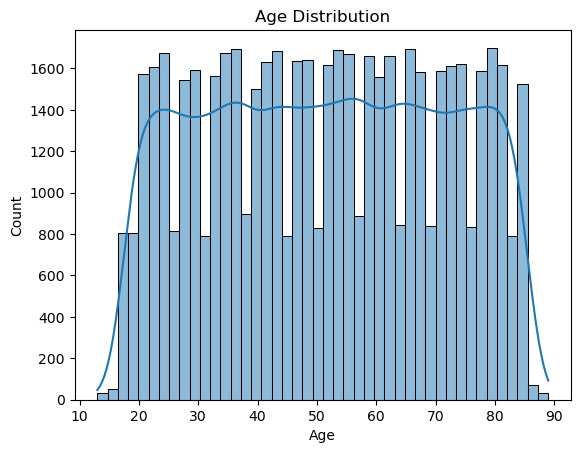

In [21]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show() # AGE DISTRIBUTION - HOW AGE IS DISTRIBUTED 

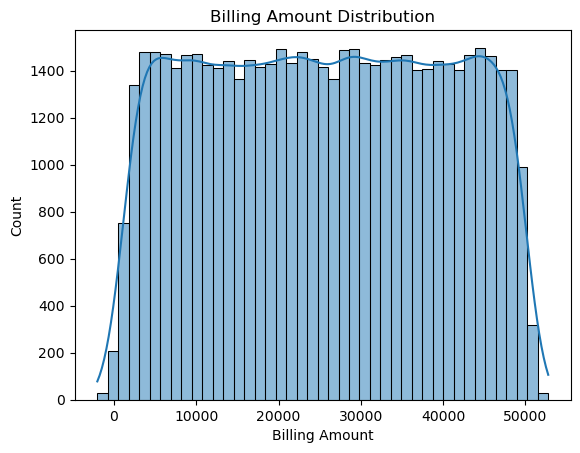

In [22]:
sns.histplot(df['Billing Amount'], kde=True)
plt.title("Billing Amount Distribution")
plt.show() # DISTRIBUTION OF BILLING AMOUNT - VERY EVENLY DISTRIBUTED - FAKE DATASET

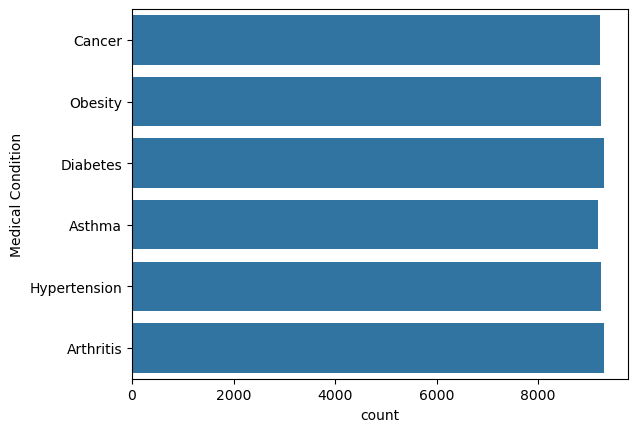

In [23]:
sns.countplot(
    data=df,
    y='Medical Condition'
)

plt.show() #MOST COMMON DISEASES


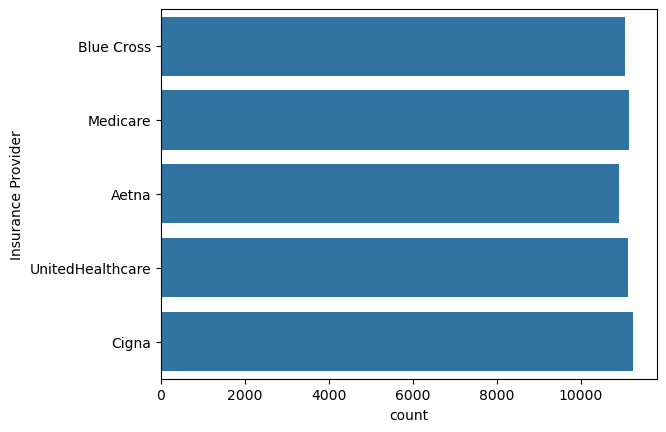

In [24]:
sns.countplot(
    data=df,
    y='Insurance Provider'
)

plt.show()

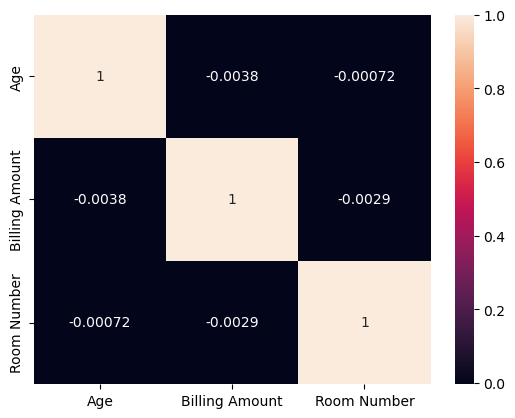

In [25]:
corr = df.select_dtypes(
    include='number'
).corr()

sns.heatmap(
    corr,
    annot=True
)

plt.show()

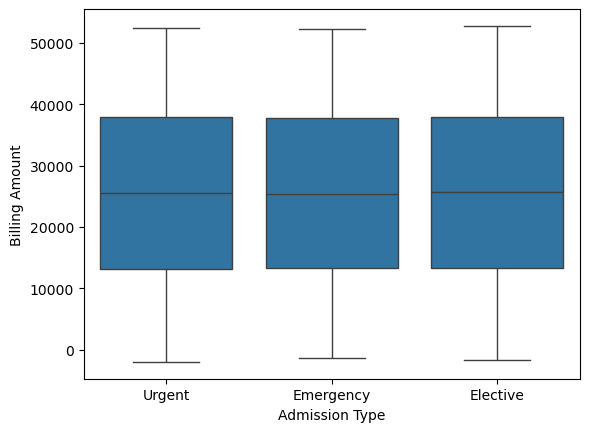

In [26]:
sns.boxplot(
    data=df,
    x='Admission Type',
    y='Billing Amount'
)

plt.show() # ADMISSION TYPE AND THE BILLING AMOUNT - HOW DIFFERENT ADMISSION TYPE GIVES DIFFERENT BILLING AMOUNT - BUT HERE VERY EVENLY DISTRUBUTED

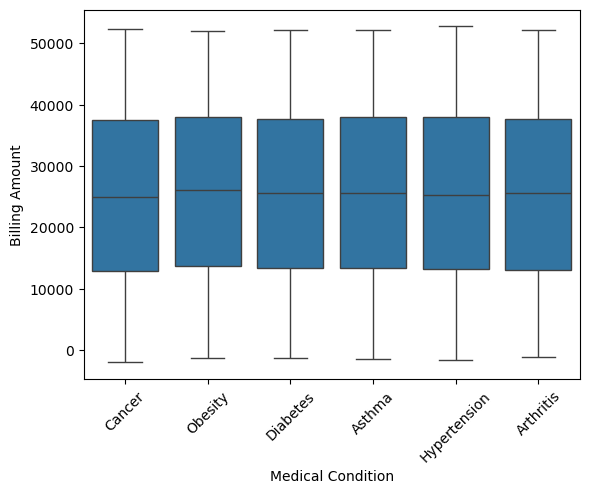

In [27]:
sns.boxplot(
    data=df,
    x='Medical Condition',
    y='Billing Amount'
)

plt.xticks(rotation=45)

plt.show() # BILLING BY DISEASE - HOW DIFFERENT DISEASE CAUSES DIFFERENT AMOUNT OF MONEY FOR CURE

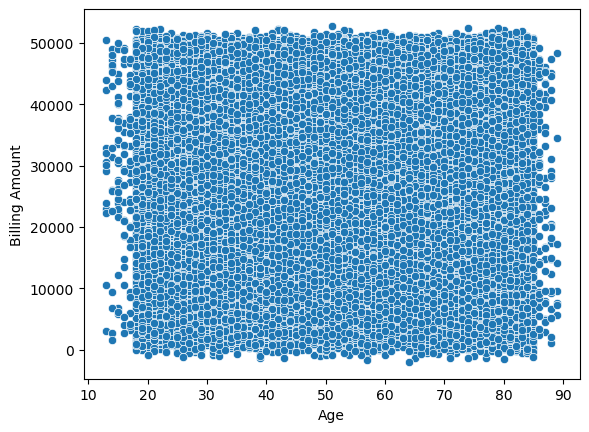

In [28]:
sns.scatterplot(
    data=df,
    x='Age',
    y='Billing Amount'
)

plt.show() # AGE VS BILLING


C:\Users\daksh\AppData\Local\Temp\ipykernel_10128\1483651015.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Billing Amount'].mean()


<Axes: xlabel='Age_Group', ylabel='Billing Amount'>

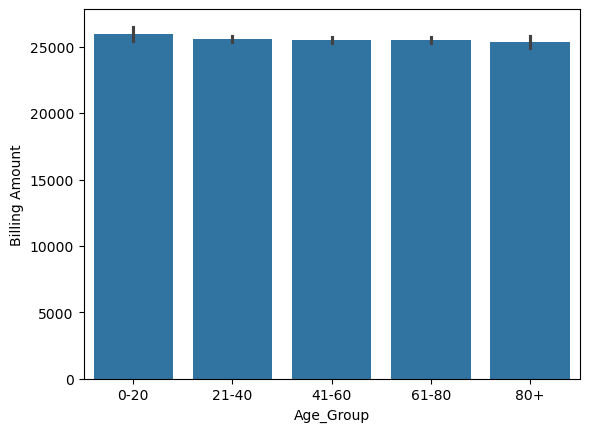

In [31]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,20,40,60,80,100],
    labels=[
        '0-20',
        '21-40',
        '41-60',
        '61-80',
        '80+'
    ]
)
df.groupby('Age_Group')['Billing Amount'].mean()
sns.barplot(
    data=df,
    x='Age_Group',
    y='Billing Amount'
)

In [32]:
hospital_stats = df.groupby('Hospital').agg({
    'Billing Amount':'mean',
    'Age':'mean'
})


<Axes: xlabel='Admission Type', ylabel='Billing Amount'>

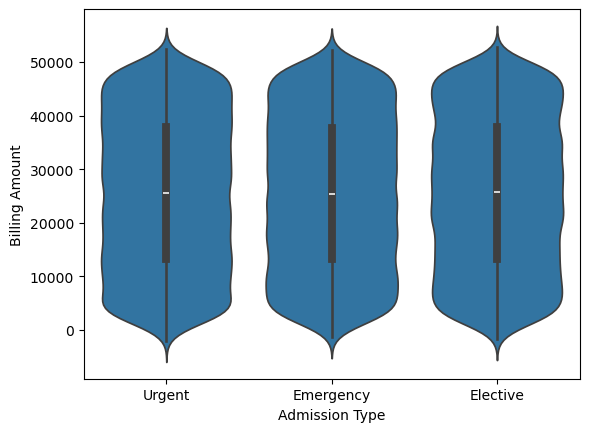

In [33]:
sns.violinplot(
    data=df,
    x='Admission Type',
    y='Billing Amount'
)

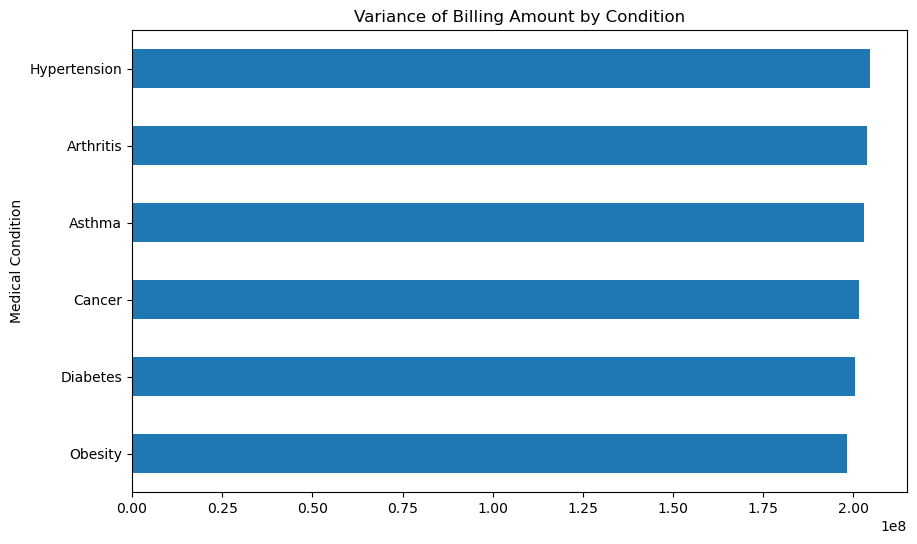

In [36]:
condition_var = (
    df.groupby('Medical Condition')
    ['Billing Amount']
    .var()
    .sort_values()
)

plt.figure(figsize=(10,6))

condition_var.plot(
    kind='barh'
)

plt.title("Variance of Billing Amount by Condition")

plt.show()

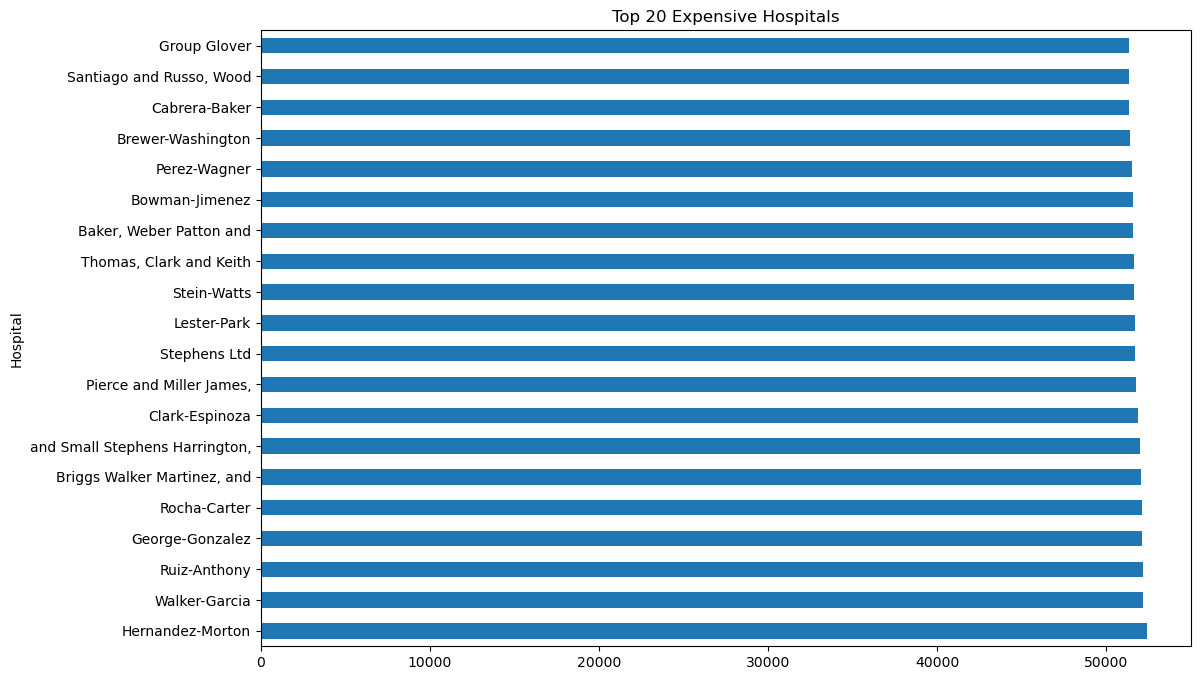

In [37]:
hospital_cost = (
    df.groupby('Hospital')
    ['Billing Amount']
    .mean()
    .sort_values(
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,8))

hospital_cost.plot(
    kind='barh'
)

plt.title(
    "Top 20 Expensive Hospitals"
)

plt.show()

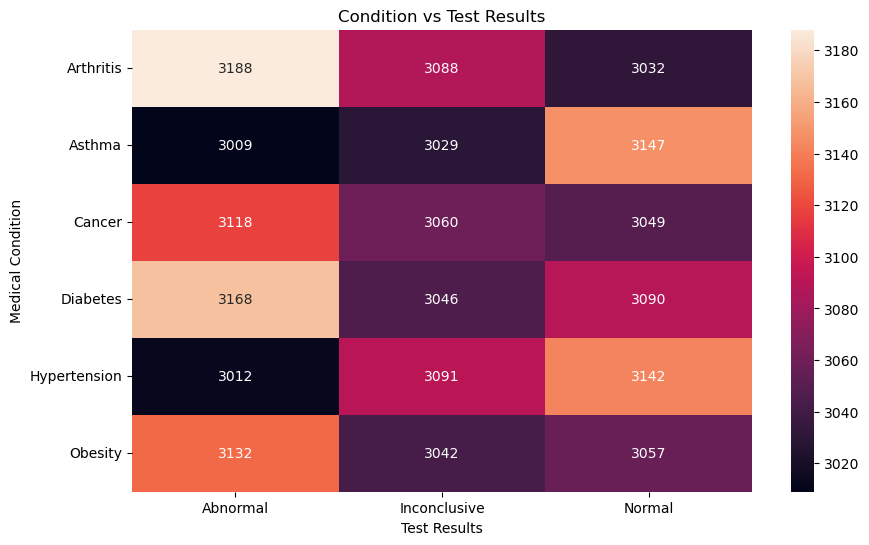

In [39]:
table = pd.crosstab(
    df['Medical Condition'],
    df['Test Results']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    table,
    annot=True,
    fmt='d'
)

plt.title(
    "Condition vs Test Results"
)

plt.show()

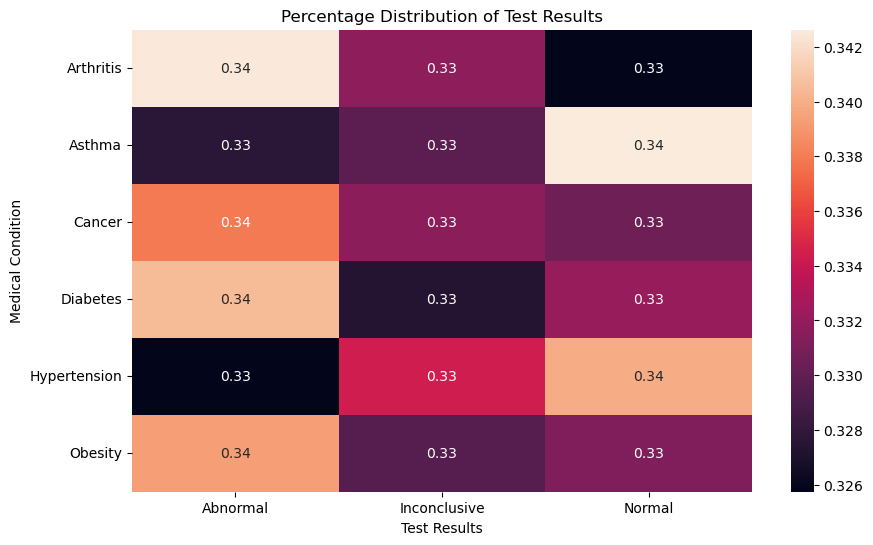

In [40]:
table = pd.crosstab(
    df['Medical Condition'],
    df['Test Results'],
    normalize='index'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    table,
    annot=True
)

plt.title(
    "Percentage Distribution of Test Results"
)

plt.show()

In [41]:
df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission']
)

df['Discharge Date'] = pd.to_datetime(
    df['Discharge Date']
)

df['Stay_Days'] = (
    df['Discharge Date']
    -
    df['Date of Admission']
).dt.days

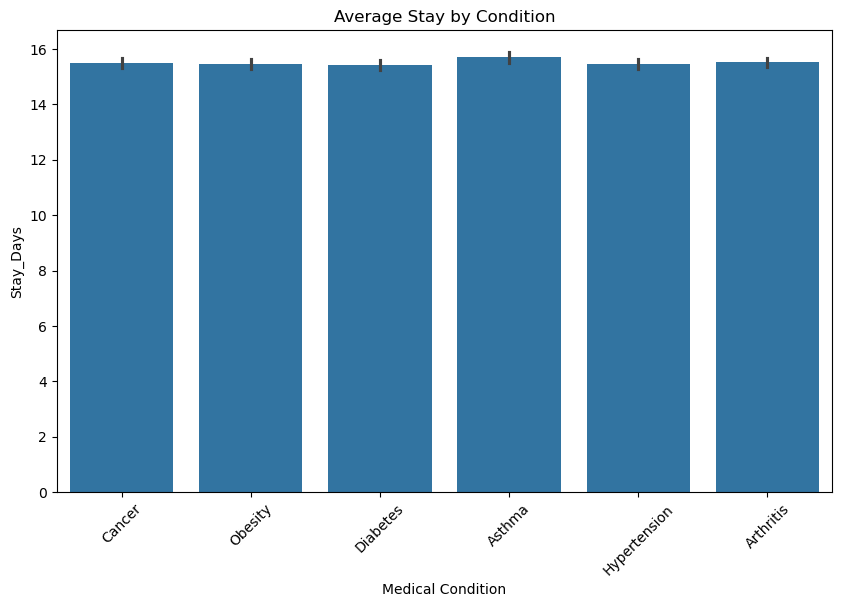

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Medical Condition',
    y='Stay_Days'
)

plt.xticks(rotation=45)

plt.title(
    "Average Stay by Condition"
)

plt.show()

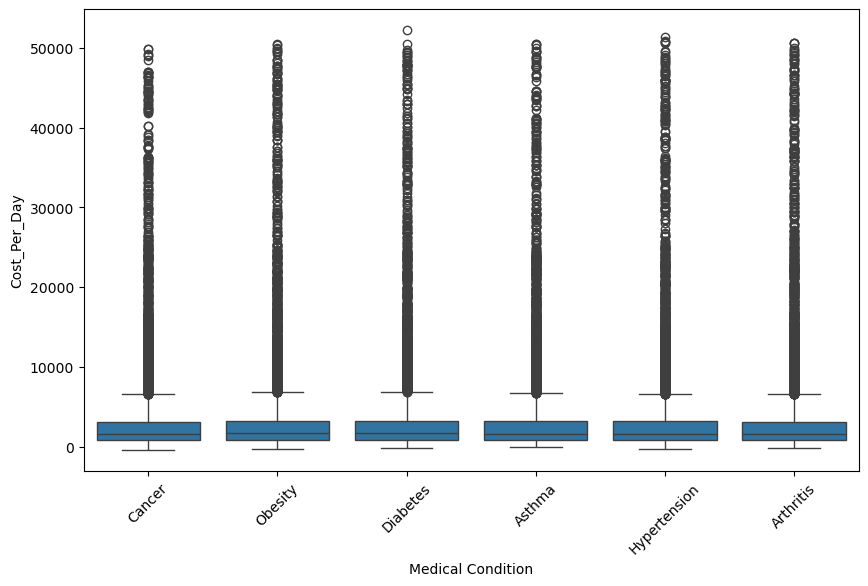

In [43]:
df['Cost_Per_Day'] = (
    df['Billing Amount']
    /
    df['Stay_Days']
)
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Medical Condition',
    y='Cost_Per_Day'
)

plt.xticks(rotation=45)

plt.show()

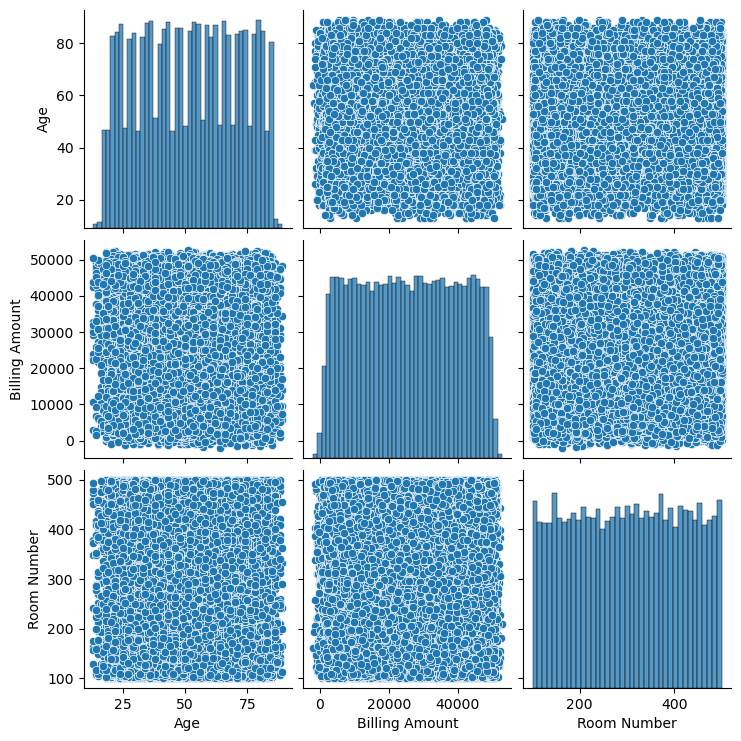

In [44]:
sns.pairplot(
    df[
        [
            'Age',
            'Billing Amount',
            'Room Number'
        ]
    ]
)

plt.show()

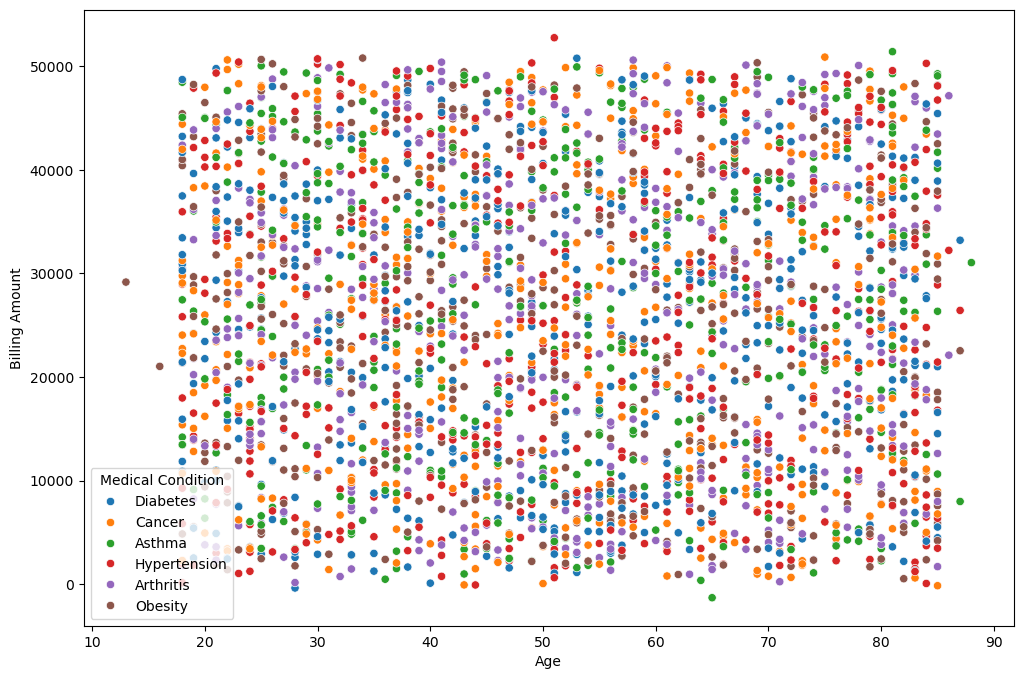

In [45]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df.sample(3000),
    x='Age',
    y='Billing Amount',
    hue='Medical Condition'
)

plt.show()